## Multiple Linear Regression

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# %matplotlib inline

In [4]:
california=fetch_california_housing()

In [5]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [9]:
##About Data
print(california['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
df = pd.DataFrame(california['data'], columns= california.feature_names)

In [10]:
df['Price_Media'] = california['target']

In [11]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price_Media
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<h4> Data Cleaning </h4>

In [ ]:
df.isnull().sum() ##non null values

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
Price_Media    0
dtype: int64

<h4> EDA </h4>

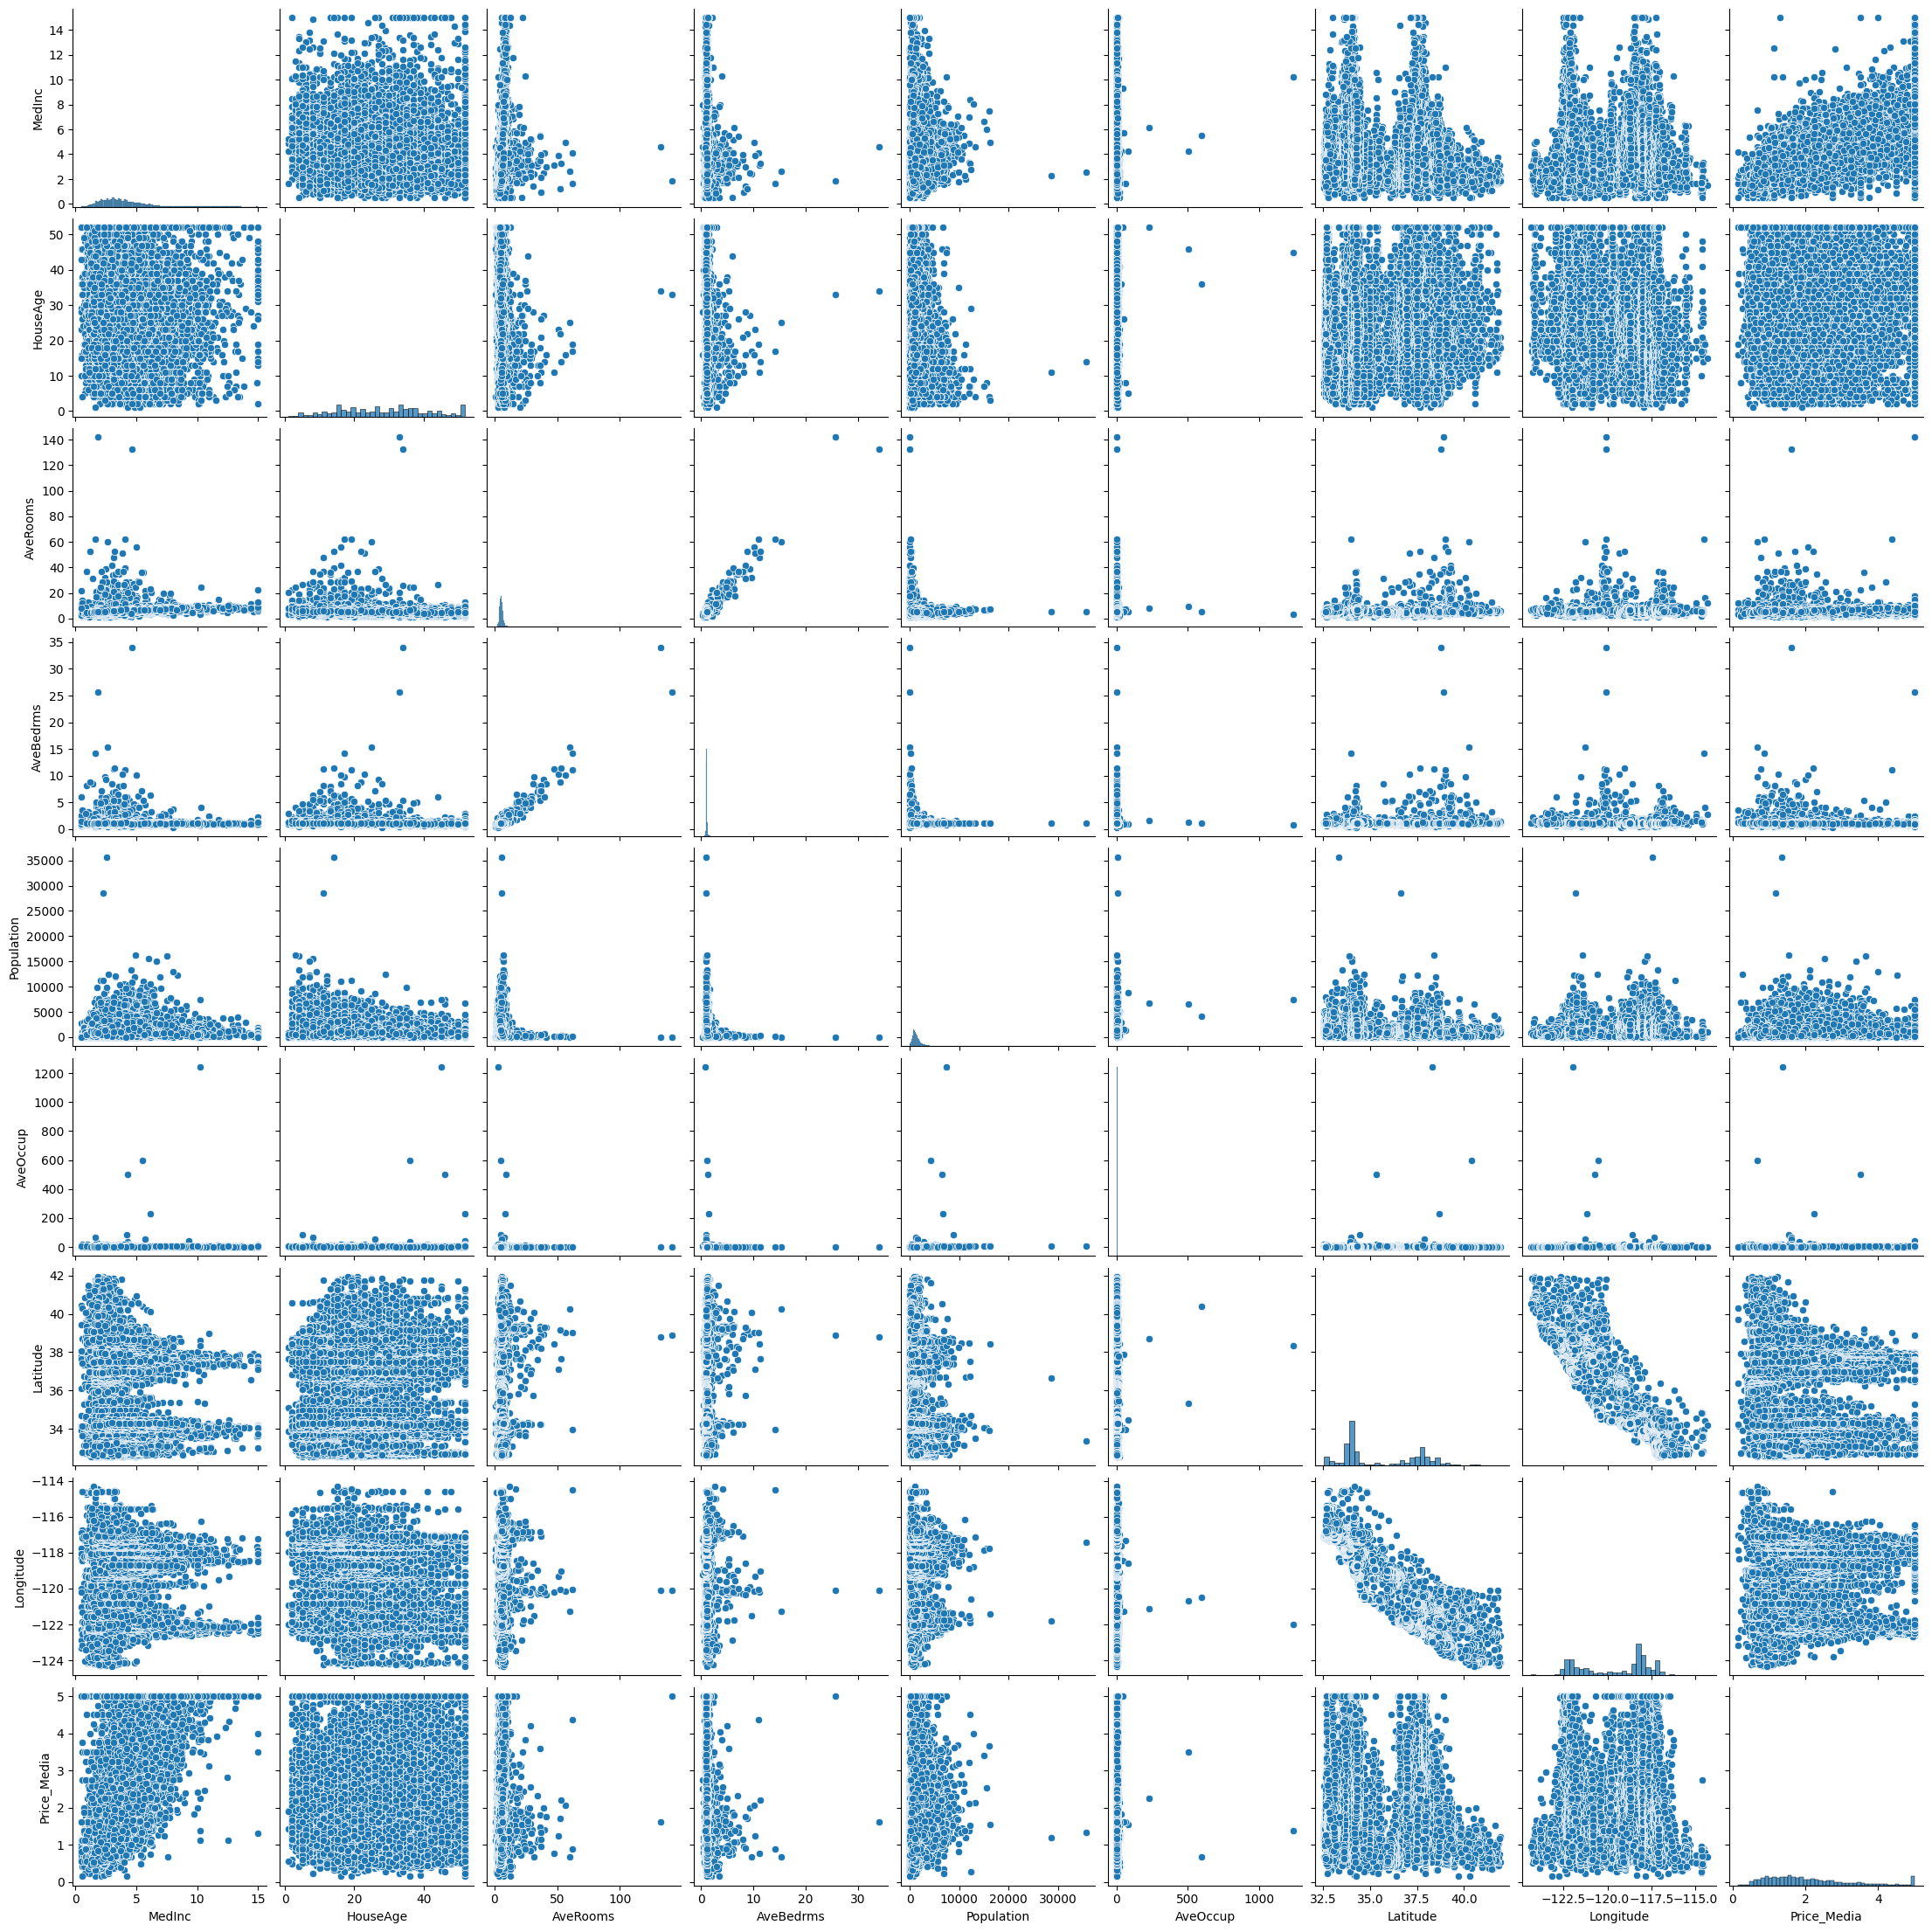

In [13]:
sns.pairplot(df)

<h5> Conclusion: No linear pattern exists in data, it seems scatterd <h5>

<h4> Data Distribution </h4>

In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price_Media'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

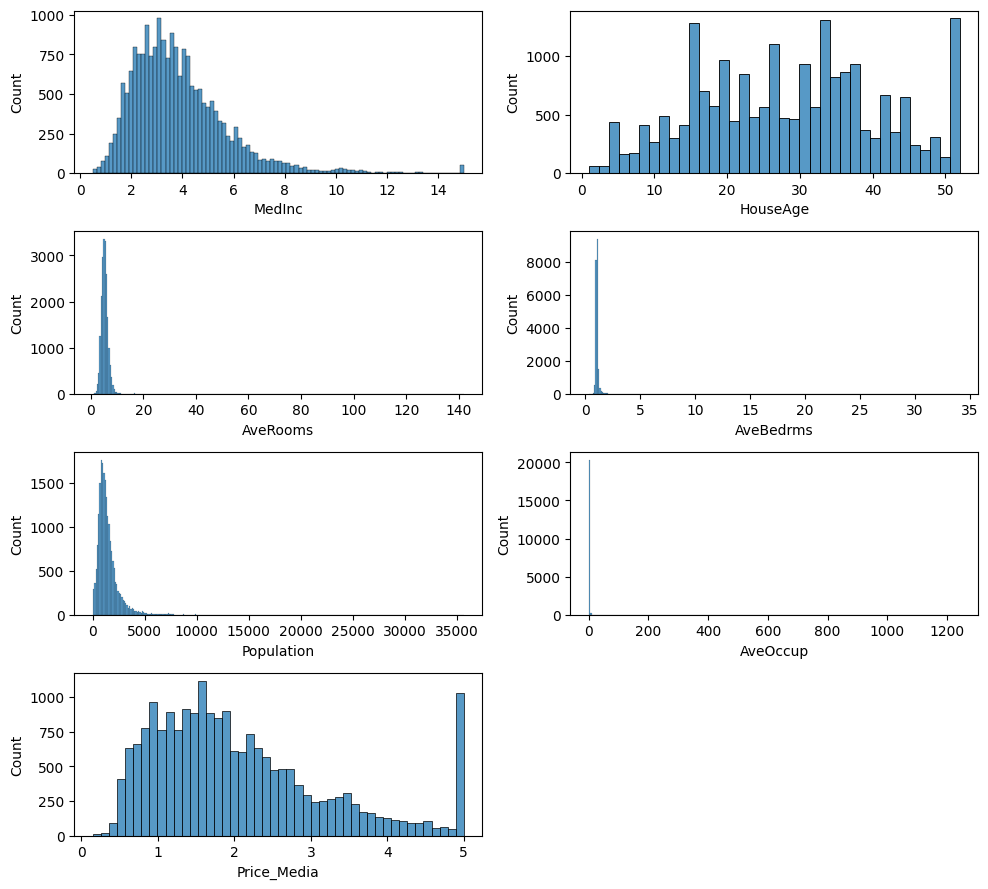

In [20]:
df.columns, len(df.columns)
plt.clf()
plt.figure(figsize=(10,9))

for j,i in enumerate(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Price_Media']):
    # plt.subplot(5,2,j+1)
    # sns.histplot(data = df, x = i)
    # if i not in ['Latitude', 'Longitude']:
    plt.subplot(4,2,j+1)
    sns.histplot(data = df, x = i)

plt.tight_layout()


<h4> Data seem skewed mostly for all the dataset </h4>
<h5> Avg Occupation seems mostly zero </h5>

(-60.0, 20000.0)

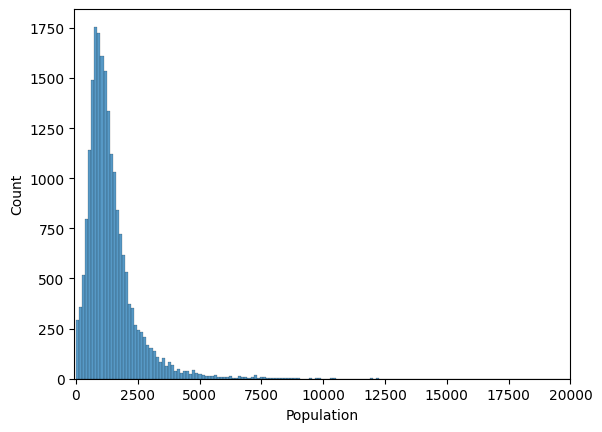

In [30]:

df['AveOccup'].value_counts()
sns.histplot(data=df,x='Population' )
plt.xlim(-60, 20000)

In [ ]:
sns.histplot(data=df,x='Population' )
plt.xlim(-1, 25)

<h4> Correlation </h4>

<Axes: >

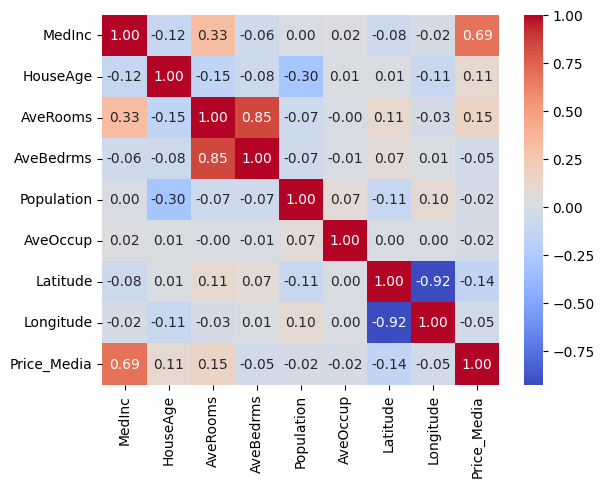

In [ ]:
sns.heatmap(df.corr(), cmap = "coolwarm",fmt ="1.2f", annot=True) 


Conclusions:
##Most features as poor explainability for Price_Median
##Avg Room, Avg Bedroom seems highly correlated

In [35]:
##Can confirm using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [36]:
vif_data = pd.DataFrame()
vif_data['Feature'] =  df.drop(columns= ['Price_Media']).columns
vif_data['VIF'] = [variance_inflation_factor( df.drop(columns= ['Price_Media']), i) \
                   for i in range(df.drop(columns= ['Price_Media']).shape[1])]

In [ ]:
vif_data ##Anything Over 10 is concerning point
##AveRooms & AveBedrms: highly correlated variables aswell
##Latitude & Longitude: Correlated to each other
##MedInc: high VIF As well

,Feature,VIF
0,MedInc,11.511140
1,HouseAge,7.195917
2,AveRooms,45.993601
3,AveBedrms,43.590314
4,Population,2.935745
5,AveOccup,1.095243
6,Latitude,559.874071
7,Longitude,633.711654


In [40]:
vif_data1 = pd.DataFrame()
vif_data1['Feature'] =  df.drop(columns= ['Price_Media','AveBedrms']).columns
vif_data1['VIF'] = [variance_inflation_factor( df.drop(columns= ['Price_Media','AveBedrms']), i) \
                   for i in range(df.drop(columns= ['Price_Media','AveBedrms']).shape[1])]

In [ ]:
vif_data1 ##this reduce VIF to significant extent

,Feature,VIF
0,MedInc,6.020853
1,HouseAge,7.171601
2,AveRooms,6.832229
3,Population,2.935230
4,AveOccup,1.095009
5,Latitude,533.285550
6,Longitude,578.148994


In [51]:
df['lat_lon'] = df['Latitude'] * df['Longitude']

In [45]:
vif_data2 = pd.DataFrame()
vif_data2['Feature'] =  df.drop(columns= ['Price_Media','AveBedrms','Latitude','Longitude']).columns
vif_data2['VIF'] = [variance_inflation_factor( df.drop(columns= ['Price_Media','AveBedrms']), i) \
                   for i in range(df.drop(columns= ['Price_Media','AveBedrms','Latitude','Longitude']).shape[1])]

In [46]:
vif_data2

,Feature,VIF
0,MedInc,6.704470
1,HouseAge,7.647535
2,AveRooms,7.328871
3,Population,2.940630
4,AveOccup,1.096111
5,lat_lon,30654.715352


In [166]:
X = df.drop(columns= ['Price_Media','lat_lon']) #'AveBedrms','Latitude','Longitude','Latitude','Longitude',
X.columns
y = df.loc[:,['Price_Media']]
y

,Price_Media
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [133]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price_Media,lat_lon
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,-4630.0724
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,-4627.2492
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,-4626.7840
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,-4627.1625
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,-4627.1625


<h3> Data Split </h3>

In [134]:
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [162]:
linear_pip = Pipeline([('preprocess', StandardScaler()), ('lr', LinearRegression())])

In [163]:
linear_pip.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [151]:
from sklearn import metrics

In [164]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,linear_pip.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,linear_pip.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,linear_pip.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst = metrics.r2_score(y_test,linear_pip.predict(X_test))
print("R2:" ,round(score_tst,3))
print("Adjusted R2:" ,round(( 1- (((1-score_tst)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),4))

MEAN ABSOLUTE ERROR: 0.53
MEAN SQUARED ERROR: 0.53
ROOT MEAN SQUARED ERROR: 0.73
R2: 0.596
Adjusted R2: 0.5952


<h4> Assumptions </h4>

Text(0.5, 0, 'Actual Y')

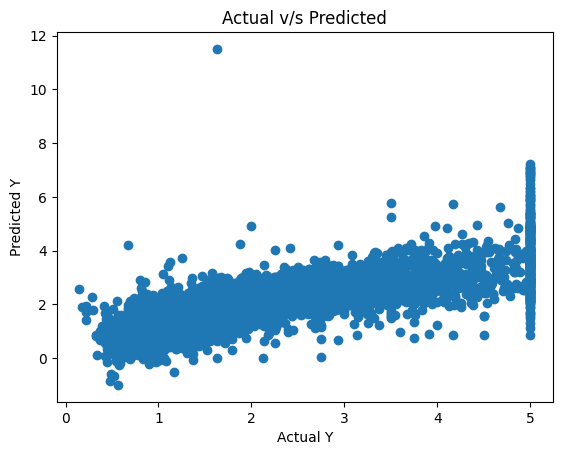

In [184]:
##Not accurate
plt.title("Actual v/s Predicted")
plt.scatter(y_test, linear_pip.predict(X_test)) ## not a diagonall which is why R2 low
plt.ylabel("Predicted Y")
plt.xlabel("Actual Y")

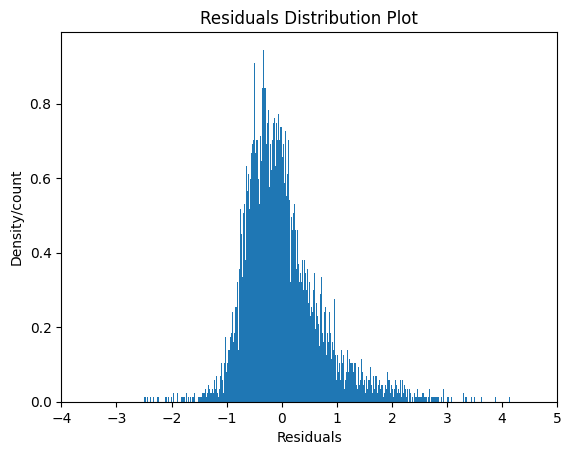

In [182]:
plt.title("Residuals Distribution Plot")
plt.hist(y_test- linear_pip.predict(X_test),bins = 1000,density= True)
plt.xlim(-4,5) ##lttle skeweness towards right
plt.ylabel("Density/count")
plt.xlabel("Residuals")
plt.show()

Text(0, 0.5, 'Residuals')

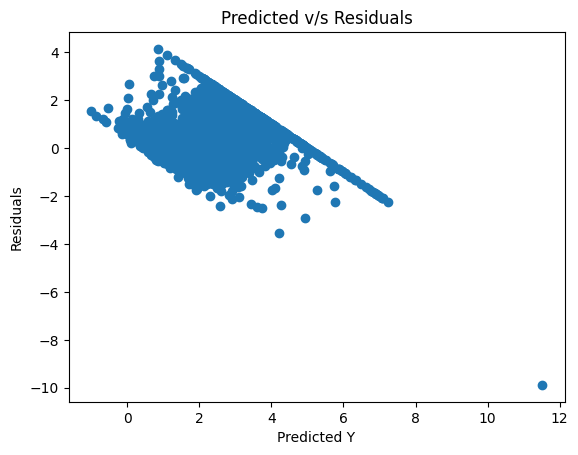

In [185]:
##Plotting residuals with respect to y: Checking Homoscedastic
plt.title("Predicted v/s Residuals")
plt.scatter(linear_pip.predict(X_test), y_test - linear_pip.predict(X_test))
plt.xlabel("Predicted Y")
plt.ylabel("Residuals")
## There is a pattern & no scatter or random not case of Homoscedastic


<h4> Positive Skewness implies actual is more than predicted => UNDERESTIMATED </h4>

<h4> Polynomial Modelling </h4>

In [186]:
from sklearn.preprocessing import PolynomialFeatures

In [202]:
poly_pip = Pipeline([('poly',PolynomialFeatures(degree= 2)),('preprocess', StandardScaler()), ('lr', LinearRegression())])

In [188]:
X = df.drop(columns= ['Price_Media','lat_lon']) #'AveBedrms','Latitude','Longitude','Latitude','Longitude',
y = df.loc[:,['Price_Media']]

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [203]:
poly_pip.fit(X_train, y_train)

,steps,"[('poly', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [204]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,poly_pip.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,poly_pip.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,poly_pip.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst1 = metrics.r2_score(y_test,poly_pip.predict(X_test))
print("R2:" ,round(score_tst1,3))
print("Adjusted R2:" ,round(( 1- (((1-score_tst1)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),4))

MEAN ABSOLUTE ERROR: 0.46
MEAN SQUARED ERROR: 0.45
ROOT MEAN SQUARED ERROR: 0.67
R2: 0.653
Adjusted R2: 0.6529


<h5> Conclusion: Polynomial little bit it improved predictability </h5>

<h5> Definitely Relation is not Linear </h5>

<h4> Ridge Regression </h4>

In [205]:
rig_pip = Pipeline([('preprocess', StandardScaler()), ('lr', Ridge())])

In [206]:
rig_pip.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


In [207]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,rig_pip.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,rig_pip.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,rig_pip.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst12 = metrics.r2_score(y_test,rig_pip.predict(X_test))
print("R2:" ,round(score_tst12,3))
print("Adjusted R2:" ,round(( 1- (((1-score_tst12)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),4))

MEAN ABSOLUTE ERROR: 0.53
MEAN SQUARED ERROR: 0.53
ROOT MEAN SQUARED ERROR: 0.73
R2: 0.596
Adjusted R2: 0.5953


In [210]:
rig_pol_pip = Pipeline([('poly',PolynomialFeatures(degree= 2)),('preprocess', StandardScaler()), ('lr', Ridge())])

In [211]:
rig_pol_pip.fit(X_train, y_train)

,steps,"[('poly', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [212]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,rig_pol_pip.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,rig_pol_pip.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,rig_pol_pip.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst13 = metrics.r2_score(y_test,rig_pol_pip.predict(X_test))
print("R2:" ,round(score_tst13,3))
print("Adjusted R2:" ,round(( 1- (((1-score_tst13)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),4))

MEAN ABSOLUTE ERROR: 0.49
MEAN SQUARED ERROR: 0.46
ROOT MEAN SQUARED ERROR: 0.68
R2: 0.653
Adjusted R2: 0.6523


<h5> Ridge & Poly Combination & Linear & Poly Combination performing same & better <h5>

<h4> Lasso </h4>

In [217]:
laso_pip = Pipeline([('preprocess', StandardScaler()), ('lasso', Lasso())])

In [218]:
laso_pip.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True


In [220]:
##Evaluation
print("MEAN ABSOLUTE ERROR:" ,round(metrics.mean_absolute_error(y_test,laso_pip.predict(X_test)),2))
print("MEAN SQUARED ERROR:" ,round(metrics.mean_squared_error(y_test,laso_pip.predict(X_test)),2)) ## Unit issue
print("ROOT MEAN SQUARED ERROR:" ,round(np.sqrt(metrics.mean_squared_error(y_test,laso_pip.predict(X_test))),2)) ## Unit issue

##R2 AND ADJUSTED R-SQUARE
score_tst14 = metrics.r2_score(y_test,laso_pip.predict(X_test))
print("R2:" ,round(score_tst14,9))
print("Adjusted R2:" ,round(( 1- (((1-score_tst14)*(X_test.shape[0]-1))/(X_test.shape[0]-X_test.shape[1]-1)) ),6))

MEAN ABSOLUTE ERROR: 0.91
MEAN SQUARED ERROR: 1.31
ROOT MEAN SQUARED ERROR: 1.15
R2: -3.931e-06
Adjusted R2: -0.001298


In [224]:
laso_pip.named_steps['lasso'].coef_ ##it reduced all to zero which seems incorrect
##which is why not checking Elastic net as it is combination of two
##clearly Ridge is Better

array([ 0.,  0.,  0., -0., -0., -0., -0., -0.])